Костин Арсений, 8Е21, вариант 3.

# Лабораторная работа №3. Работа с видеопотоком

<p>Цель: Научиться анализировать видеопоток.
<p>Ход работы: получить видеопоток с Web-камеры и определить перемещающийся в кадре объект. Используя данные видеопотока реализуйте следующее:
<p> 1. Реализуйте получение данных с Web-камеры
<p> 2. Реализуйте алгоритм вычитания фона
<p> 3. Реализуйте определение движущегося предмета
<p> 4. Постройте траекторию движения объекта.
<p> 5. Проведите тестирование на тестовом видео.
<p> Проверка работоспособности: будет осуществляться на специальном видео, предоставленным преподавателем. Траектория движения, для которых недоступна.

In [23]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image
%matplotlib inline
import math
import time
import lab1_functions as lb1
import lab2_functions as lb2
from collections import deque
import os
print(os.getcwd())
print(os.listdir())

d:\Libraries\Documents\VScode\CV_labs_Plotnikov_8E21\Lab_3
['CV_lab_3_Plotnikov_8E21.ipynb', 'lab1_functions.py', 'lab2_functions.py', 'lab3.ipynb', 'lab3_functions.py', 'lab3_output', 'mouse_1.avi', '__pycache__']


In [24]:
# Проверка доступных камер
for i in range(10):
    cap = cv2.VideoCapture(i)
    if cap.isOpened():
        print(f"Камера {i} доступна")
        ret, frame = cap.read()
        if ret:
            print(f"  - Успешное чтение кадра, размер: {frame.shape}")
        cap.release()
    else:
        print(f"Камера {i} недоступна")

Камера 0 доступна
Камера 1 недоступна
Камера 2 недоступна
Камера 3 недоступна
Камера 4 недоступна
Камера 5 недоступна
Камера 6 недоступна
Камера 7 недоступна
Камера 8 недоступна
Камера 9 недоступна


# 3.1 Получить видеопоток с веб-камеры

Запись разбита на два отдельных шага — фон и движение — чтобы можно было переснять каждый независимо.

### Шаг 1 — запись фона

Запускаем ячейку, убираем всё из кадра и ждём 3 секунды. Консоль тикает каждую секунду. После записи показываем первый и последний кадр — проверяем что в кадре пусто.

ФОН
Держите кадр ПУСТЫМ в течение 3 секунд...
...
...
...
Записано кадров фона: 30


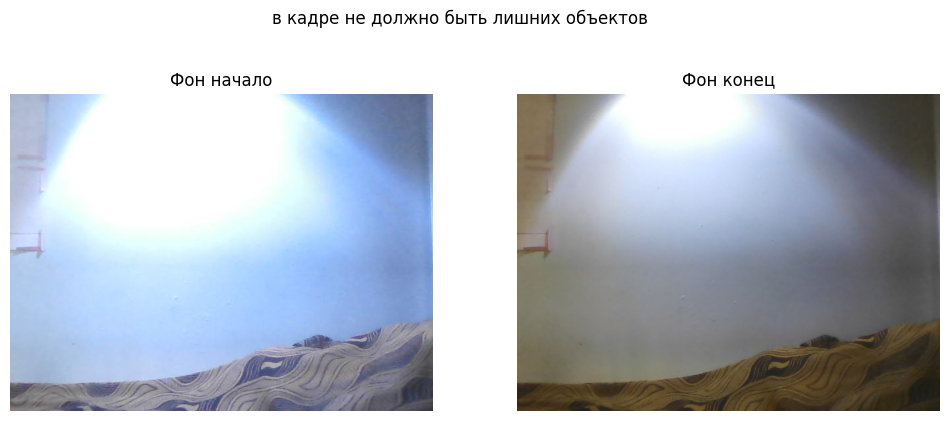

In [30]:
BG_SECONDS  = 3
FPS_APPROX  = 10
N_BG_FRAMES = BG_SECONDS * FPS_APPROX

cap = cv2.VideoCapture(0)

print('ФОН')
print(f'Держите кадр ПУСТЫМ в течение {BG_SECONDS} секунд...')

bg_frames = []
for i in range(N_BG_FRAMES):
    ret, frame = cap.read()
    if ret:
        bg_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    if i % FPS_APPROX == 0:
        print('...')
    cv2.waitKey(100)

cap.release()
print(f'Записано кадров фона: {len(bg_frames)}')

f, axarr = plt.subplots(1, 2, figsize=(12, 5))
axarr[0].imshow(bg_frames[0])
axarr[0].set_title('Фон начало')
axarr[1].imshow(bg_frames[-1])
axarr[1].set_title('Фон конец')
for ax in axarr: ax.axis('off')
plt.suptitle('в кадре не должно быть лишних объектов')
plt.show()

### Шаг 2 — запись движения

После старта идёт обратный отсчёт 3 ... 1, вносим объект и плавно двигаем его по кадру 5 секунд.

запись
  Старт через 3...
  Старт через 2...
  Старт через 1...
двигаем
...
...
...
...
...
Записано кадров движения: 50


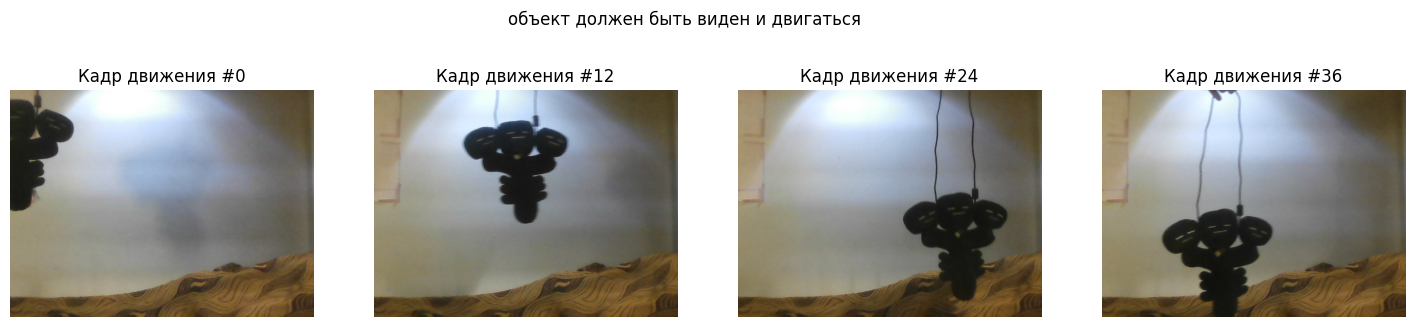

In [32]:
COUNTDOWN_SEC  = 3
MOTION_SECONDS = 5
N_MOT_FRAMES   = MOTION_SECONDS * FPS_APPROX

cap = cv2.VideoCapture(0)

print('запись')
for s in range(COUNTDOWN_SEC, 0, -1):
    print(f'  Старт через {s}...')
    time.sleep(1)
print('двигаем')

motion_frames = []
for i in range(N_MOT_FRAMES):
    ret, frame = cap.read()
    if ret:
        motion_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    if i % FPS_APPROX == 0:
        print(f'...')
    cv2.waitKey(100)

cap.release()
frames_sequence = bg_frames + motion_frames
print(f'Записано кадров движения: {len(motion_frames)}')

step = max(1, len(motion_frames) // 4)
f, axarr = plt.subplots(1, 4, figsize=(18, 4))
for i, ax in enumerate(axarr):
    idx = min(i * step, len(motion_frames) - 1)
    ax.imshow(motion_frames[idx])
    ax.set_title(f'Кадр движения #{idx}')
    ax.axis('off')
plt.suptitle('объект должен быть виден и двигаться')
plt.show()

# 3.2 Инициализировать вычитатель фона

Берём все кадры фона и считаем попиксельное среднее — это и есть наша модель фона. Логика та же, что и при любом усреднении: случайные отклонения из-за шума камеры компенсируют друг друга, остаётся стабильная картина пустой сцены.

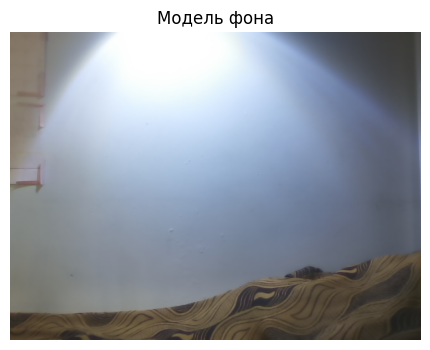

In [33]:
def build_background(frames):
    bg = np.zeros_like(frames[0], dtype=float)
    for f in frames:
        bg += f.astype(float)
    bg /= len(frames)
    return bg

background = build_background(bg_frames)

plt.figure(figsize=(6, 4))
plt.imshow(background.astype(np.uint8))
plt.title('Модель фона')
plt.axis('off')
plt.show()

# 3.3 Применить вычитание фона к кадру

Для каждого кадра считаем абсолютную разность с фоном по каждому каналу RGB. Потом усредняем разность по трём каналам — получаем одноканальное изображение, где яркость пикселя = насколько сильно он отличается от фона.

In [73]:
THRESHOLD = 41
def subtract_background(frame, bg, threshold):
    diff      = np.abs(frame.astype(float) - bg)
    diff_gray = (diff[:, :, 0] + diff[:, :, 1] + diff[:, :, 2]) / 3.0
    mask      = np.zeros(diff_gray.shape, dtype=np.uint8)
    mask[diff_gray > threshold] = 255
    return diff_gray, mask

# 3.4 Получить маску переднего плана (foreground mask)

Применяем вычитание к тестовому кадру. Всё что ярче порога — бинаризуется в белый (255), остальное — чёрный (0). Белые пиксели — кандидаты в «движущийся объект».

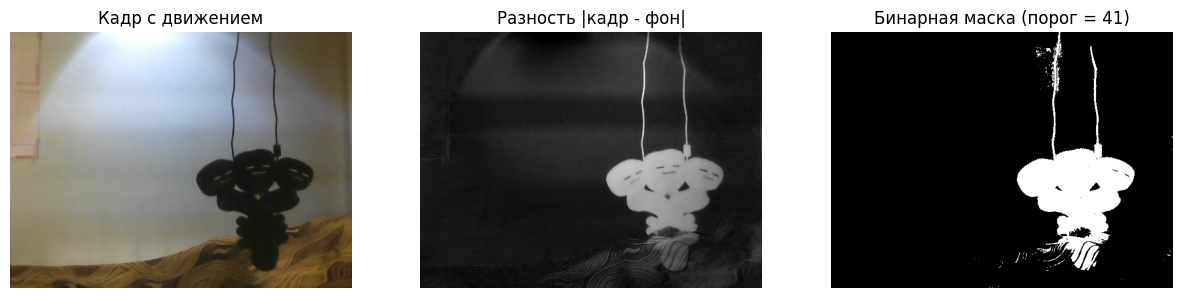

In [74]:
frame_test = motion_frames[len(motion_frames) // 2]

diff_gray_test, mask_test = subtract_background(frame_test, background, THRESHOLD)

f, axarr = plt.subplots(1, 3, figsize=(15, 5))
axarr[0].imshow(frame_test)
axarr[0].set_title('Кадр с движением')
axarr[1].imshow(diff_gray_test, cmap='gray')
axarr[1].set_title('Разность |кадр - фон|')
axarr[2].imshow(mask_test, cmap='gray')
axarr[2].set_title(f'Бинарная маска (порог = {THRESHOLD})')
for ax in axarr: ax.axis('off')
plt.show()

# 3.5 Очистить маску (морфология, шумоподавление)

Сырая маска шумная — на ней много мелких белых пятен от перепадов освещения и шума камеры. Применяем морфологическое открытие: сначала эрозия уничтожает мелкие пятна, потом дилатация возвращает размер оставшимся (настоящим) объектам.

В лабе 1 эрозия и дилатация были реализованы через тройные питоновские циклы — на одном изображении это нормально, но на 50 кадрах видео работало бы более 5 минут. Поэтому здесь делаем то же самое, но через numpy-операции: скользящее минимальное/максимальное по окну через `np.lib.stride_tricks`. Результат идентичный — только быстро.

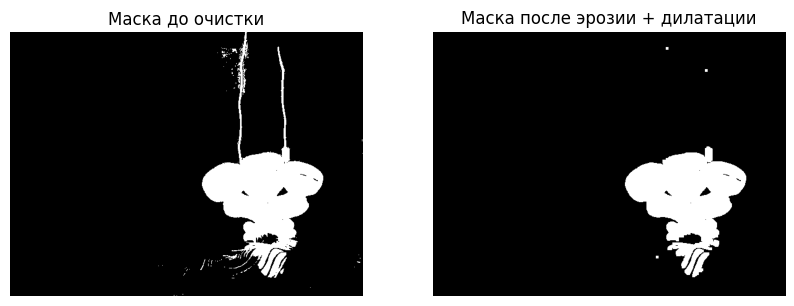

In [75]:
def fast_erode(mask_bin, size=5):
    pad = size // 2
    padded = np.pad(mask_bin, pad, mode='constant', constant_values=1)
    h, w = mask_bin.shape

    windows = np.lib.stride_tricks.sliding_window_view(padded, (size, size))
    return windows.min(axis=(-2, -1)).astype(np.uint8)

def fast_dilate(mask_bin, size=5):
    pad = size // 2
    padded = np.pad(mask_bin, pad, mode='constant', constant_values=0)
    windows = np.lib.stride_tricks.sliding_window_view(padded, (size, size))
    return windows.max(axis=(-2, -1)).astype(np.uint8)

def clean_mask(mask_uint8, morph_size=5):
    mask_bin = (mask_uint8 // 255).astype(np.uint8)
    eroded   = fast_erode(mask_bin,  morph_size)
    dilated  = fast_dilate(eroded,   morph_size)
    return (dilated * 255).astype(np.uint8)

mask_cleaned = clean_mask(mask_test, morph_size=5)

f, axarr = plt.subplots(1, 2, figsize=(10, 5))
axarr[0].imshow(mask_test,    cmap='gray')
axarr[0].set_title('Маска до очистки')
axarr[1].imshow(mask_cleaned, cmap='gray')
axarr[1].set_title('Маска после эрозии + дилатации')
for ax in axarr: ax.axis('off')
plt.show()

# 3.6 Найти контуры движущихся объектов

Контурный пиксель — белый пиксель маски, у которого хотя бы один из четырёх соседей чёрный. То есть он стоит на границе объекта. Проходим по всей маске и собираем такие пиксели в список.

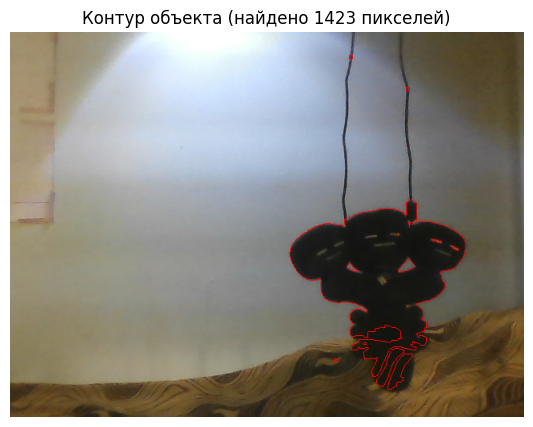

In [76]:
def find_contour_pixels(mask_uint8):
    m    = mask_uint8
    inner = m[1:-1, 1:-1]
    is_white    = inner == 255
    has_black_neighbor = (
        (m[0:-2, 1:-1] == 0) |
        (m[2:,   1:-1] == 0) |
        (m[1:-1, 0:-2] == 0) |
        (m[1:-1, 2:]   == 0)
    )
    contour_map = is_white & has_black_neighbor
    rows, cols  = np.where(contour_map)
    return list(zip(rows + 1, cols + 1))

contour_pixels = find_contour_pixels(mask_cleaned)

frame_with_contour = frame_test.copy()
for (r, c) in contour_pixels:
    frame_with_contour[r, c] = [255, 0, 0]

plt.figure(figsize=(7, 5))
plt.imshow(frame_with_contour)
plt.title(f'Контур объекта (найдено {len(contour_pixels)} пикселей)')
plt.axis('off')
plt.show()

# 3.7 Определить и отфильтровать объекты по размеру

На маске может быть несколько белых областей — часть из них шум, который не убрала морфология. Чтобы найти отдельные объекты, используем обход в ширину (BFS): стартуем из непосещённого белого пикселя, обходим все связные с ним — это один объект. Повторяем для всех оставшихся. Компоненты с площадью меньше `min_area` отбрасываем как шум.

In [77]:
def connected_components(mask_uint8, min_area=300):
    visited    = np.zeros_like(mask_uint8, dtype=bool)
    h, w       = mask_uint8.shape
    components = []

    for r in range(h):
        for c in range(w):
            if mask_uint8[r, c] == 255 and not visited[r, c]:
                queue     = deque([(r, c)])
                visited[r, c] = True
                component = []
                while queue:
                    cr, cc = queue.popleft()
                    component.append((cr, cc))
                    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                        nr, nc = cr+dr, cc+dc
                        if 0 <= nr < h and 0 <= nc < w:
                            if mask_uint8[nr, nc] == 255 and not visited[nr, nc]:
                                visited[nr, nc] = True
                                queue.append((nr, nc))
                if len(component) >= min_area:
                    components.append(component)

    return components

components = connected_components(mask_cleaned, min_area=300)
print(f'Найдено объектов после фильтрации по площади: {len(components)}')
for i, comp in enumerate(components):
    print(f'  Объект {i}: {len(comp)} пикселей')

Найдено объектов после фильтрации по площади: 3
  Объект 0: 24409 пикселей
  Объект 1: 546 пикселей
  Объект 2: 575 пикселей


# 3.8 Вычислить центроид и bounding box объекта

Центроид — «центр масс» компоненты, то есть среднее по строкам и столбцам всех её пикселей. Bounding box — минимальный охватывающий прямоугольник, находим через min/max строк и столбцов.

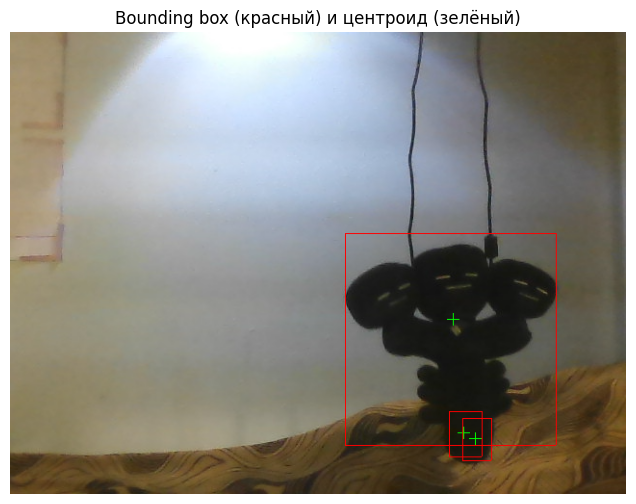

In [78]:
def get_centroid_and_bbox(component):
    px = np.array(component)
    centroid_r = px[:, 0].mean()
    centroid_c = px[:, 1].mean()
    r0, c0 = px[:, 0].min(), px[:, 1].min()
    r1, c1 = px[:, 0].max(), px[:, 1].max()
    return (centroid_c, centroid_r), (r0, c0, r1, c1)

vis_frame = frame_test.copy()
for comp in components:
    (cx, cy), (r0, c0, r1, c1) = get_centroid_and_bbox(comp)
    vis_frame[r0, c0:c1] = [255, 0, 0]
    vis_frame[r1, c0:c1] = [255, 0, 0]
    vis_frame[r0:r1, c0] = [255, 0, 0]
    vis_frame[r0:r1, c1] = [255, 0, 0]
    cr, cc = int(cy), int(cx)
    for d in range(-6, 7):
        if 0 <= cr+d < vis_frame.shape[0]: vis_frame[cr+d, cc] = [0, 255, 0]
        if 0 <= cc+d < vis_frame.shape[1]: vis_frame[cr, cc+d] = [0, 255, 0]

plt.figure(figsize=(8, 6))
plt.imshow(vis_frame)
plt.title('Bounding box (красный) и центроид (зелёный)')
plt.axis('off')
plt.show()

# 3.9 Накопить координаты центроида и построить траекторию

Запускаем полный конвейер по всем кадрам движения. На каждом кадре: вычитание фона → очистка маски → поиск компонент → берём самую большую → запоминаем центроид. Если объект не найден — пишем `None`.

Траекторию строим через `lb2.draw_trajectory_generic` из второй лабы.

Кадров движения обработано: 50
Кадров с обнаруженным объектом: 50


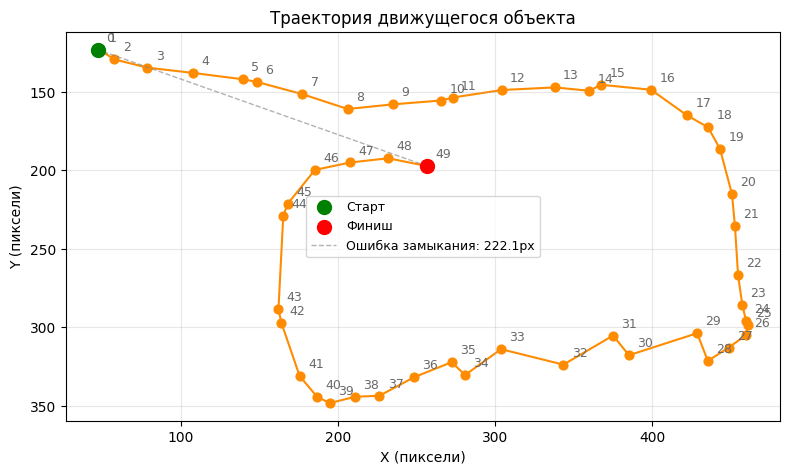

In [79]:
MIN_AREA   = 300
trajectory = []

for idx, frame in enumerate(motion_frames):
    _, mask = subtract_background(frame, background, THRESHOLD)
    mask_cl = clean_mask(mask, morph_size=5)
    comps   = connected_components(mask_cl, min_area=MIN_AREA)

    if comps:
        largest     = max(comps, key=lambda c: len(c))
        (cx, cy), _ = get_centroid_and_bbox(largest)
        trajectory.append((cx, cy))
    else:
        trajectory.append(None)

detected = sum(1 for t in trajectory if t is not None)
print(f'Кадров движения обработано: {len(motion_frames)}')
print(f'Кадров с обнаруженным объектом: {detected}')

if detected == 0:
    print('Объект не найден')

valid_traj  = [(i, p) for i, p in enumerate(trajectory) if p is not None]
pos_list    = [p for p in trajectory if p is not None]
labels_list = [str(i) for i, _ in valid_traj]

if pos_list:
    lb2.draw_trajectory_generic(
        pos_list,
        image_labels=labels_list,
        title='Траектория движущегося объекта',
        color='darkorange'
    )

# 3.10 Отобразить результаты (оригинал + маска + траектория + bounding box)

Финальная сводная визуализация. Берём первый кадр, где объект обнаружен, и показываем четыре этапа рядом. На последнем — рисуем накопленную траекторию линиями через алгоритм Брезенхема (рисует прямую попиксельно, без `cv2.line`).

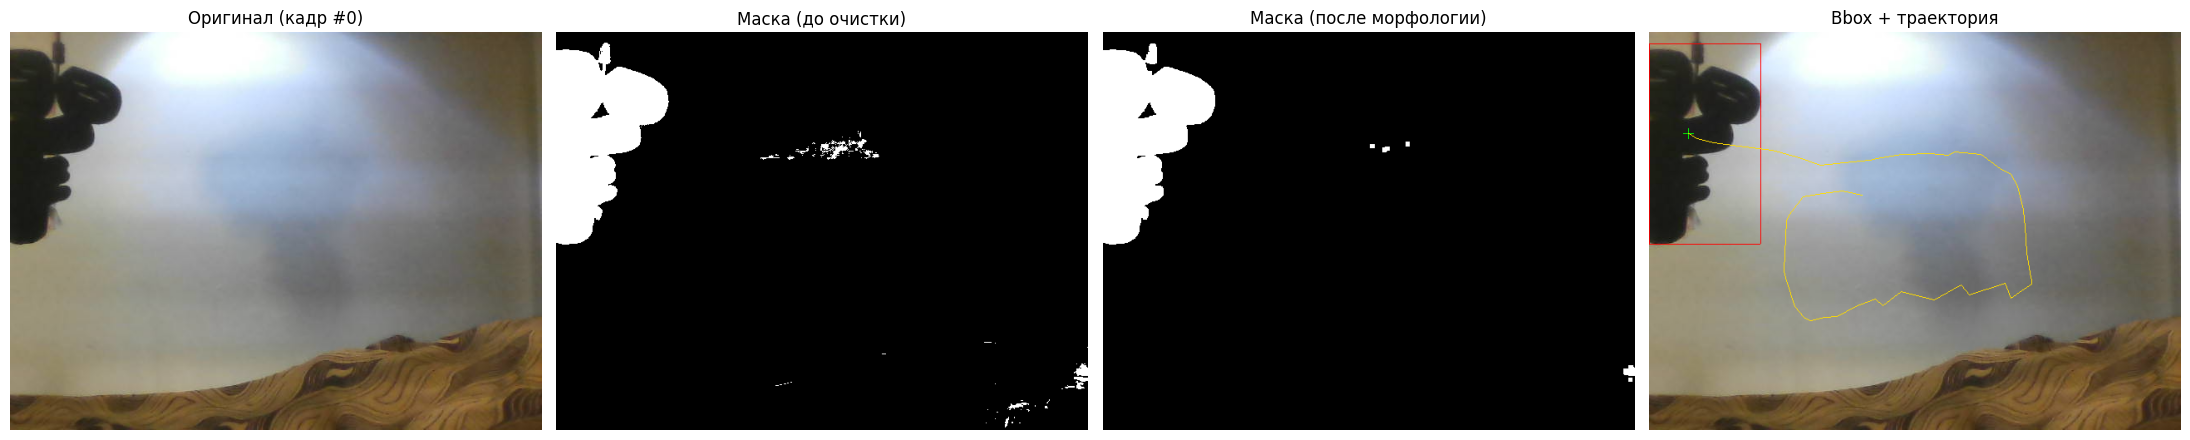

In [80]:
def bresenham_line(img, x0, y0, x1, y1, color):
    dx, dy = abs(x1-x0), abs(y1-y0)
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    err = dx - dy
    while True:
        if 0 <= y0 < img.shape[0] and 0 <= x0 < img.shape[1]:
            img[y0, x0] = color
        if x0 == x1 and y0 == y1:
            break
        e2 = 2 * err
        if e2 > -dy: err -= dy; x0 += sx
        if e2 <  dx: err += dx; y0 += sy

best_idx   = next((i for i, t in enumerate(trajectory) if t is not None), 0)
best_frame = motion_frames[best_idx]

_, mask_best = subtract_background(best_frame, background, THRESHOLD)
mask_best_cl = clean_mask(mask_best, morph_size=5)
comps_best   = connected_components(mask_best_cl, min_area=MIN_AREA)

frame_result = best_frame.copy()
for comp in comps_best:
    (cx, cy), (r0, c0, r1, c1) = get_centroid_and_bbox(comp)
    frame_result[r0, c0:c1] = [255, 0, 0]
    frame_result[r1, c0:c1] = [255, 0, 0]
    frame_result[r0:r1, c0] = [255, 0, 0]
    frame_result[r0:r1, c1] = [255, 0, 0]
    cr, cc = int(cy), int(cx)
    for d in range(-6, 7):
        if 0 <= cr+d < frame_result.shape[0]: frame_result[cr+d, cc] = [0, 255, 0]
        if 0 <= cc+d < frame_result.shape[1]: frame_result[cr, cc+d] = [0, 255, 0]

prev_pt = None
for pt in trajectory:
    if pt is None:
        prev_pt = None
        continue
    px, py = int(pt[0]), int(pt[1])
    if prev_pt is not None:
        bresenham_line(frame_result, int(prev_pt[0]), int(prev_pt[1]), px, py, [255, 220, 0])
    if 0 <= py < frame_result.shape[0] and 0 <= px < frame_result.shape[1]:
        frame_result[py, px] = [255, 255, 0]
    prev_pt = pt

f, axarr = plt.subplots(1, 4, figsize=(22, 5))
axarr[0].imshow(best_frame)
axarr[0].set_title(f'Оригинал (кадр #{best_idx})')
axarr[1].imshow(mask_best, cmap='gray')
axarr[1].set_title('Маска (до очистки)')
axarr[2].imshow(mask_best_cl, cmap='gray')
axarr[2].set_title('Маска (после морфологии)')
axarr[3].imshow(frame_result)
axarr[3].set_title('Bbox + траектория')
for ax in axarr: ax.axis('off')
plt.tight_layout()
plt.show()

# Вывод

В ходе лабораторной работы реализован полный конвейер обнаружения и трекинга движущегося объекта без использования готовых алгоритмов OpenCV.

Модель фона строится как попиксельное среднее по кадрам пустой сцены. Вычитание фона выполняется через абсолютную разность с последующей бинаризацией по порогу. Морфологическое открытие (эрозия + дилатация) реализовано через скользящие numpy-окна (`stride_tricks`) — это сохраняет логику операций из лабы 1, но работает на всём видео за секунды вместо минут. Поиск объектов выполнен BFS по связным компонентам с фильтрацией по площади. Центроид и bounding box вычисляются аналитически через min/max/mean по координатам пикселей. Траектория строится через `lb2.draw_trajectory_generic`, отрисовка линий — алгоритмом Брезенхема.